# Handoffs

In the **handoffs** architecture, behavior changes dynamically based on state. The core mechanism: `tools` update a state variable (e.g., `current_step` or `active_agent`) that persists across turns, and the system reads this variable to adjust behavior — either applying different configuration (system prompt, tools) or routing to a different `agent`. This pattern supports both handoffs between distinct agents and dynamic configuration changes within a single agent.

<Tip>

  The term **handoffs** was coined by [OpenAI](https://openai.github.io/openai-agents-python/handoffs/) for using tool calls (e.g., `transfer_to_sales_agent`) to transfer control between agents or states.
</Tip>

![alt text](./agent-handoffs.png)

## Key characteristics

* State-driven behavior: Behavior changes based on a state variable (e.g., `current_step` or `active_agent`)
* Tool-based transitions: Tools update the state variable to move between states
* Direct user interaction: Each state's configuration handles user messages directly
* Persistent state: State survives across conversation turns

## When to use

Use the handoffs pattern when you need to **enforce sequential constraints** (unlock capabilities only after preconditions are met), the agent needs to converse directly with the user across different states, or you're building multi-stage conversational flows. This pattern is particularly valuable for customer support scenarios where you need to collect information in a specific sequence — for example, collecting a warranty ID before processing a refund.

## Basic implementation

The core mechanism is a `tool` that returns a `Command` to update state (and not an usual tool response), triggering a transition to a new step or agent:

```python  theme={null}
from langchain.tools import tool
from langchain.messages import ToolMessage
from langgraph.types import Command

@tool
def transfer_to_specialist(runtime) -> Command:
    """Transfer to the specialist agent."""
    return Command(
        update={
            "messages": [
                ToolMessage(  
                    content="Transferred to specialist",
                    tool_call_id=runtime.tool_call_id  
                )
            ],
            "current_step": "specialist"  # Triggers behavior change
        }
    )
```

<Note>

  **Why include a `ToolMessage`?** When an LLM calls a tool, it expects a response. The `ToolMessage` with matching `tool_call_id` completes this request-response cycle—without it, the conversation history becomes malformed. This is required whenever your handoff tool updates messages.
</Note>

## Implementation approaches

There are two ways to implement handoffs: **single agent with middleware** (one agent with dynamic configuration) or **multiple agent subgraphs** (distinct agents as graph nodes).

### Single agent with middleware

A single agent changes its behavior based on state. Middleware intercepts each model call and dynamically adjusts the system prompt and available tools. Tools update the state variable to trigger transitions:

### Multiple agent subgraphs

Multiple distinct agents exist as separate nodes in a graph. Handoff tools navigate between agent nodes using `Command.PARENT` to specify which node to execute next.

<Warning>

  Subgraph handoffs require careful **context engineering**. Unlike single-agent middleware (where message history flows naturally), you must explicitly decide what messages pass between agents. Get this wrong and agents receive malformed conversation history or bloated context. 
</Warning>

```python  
from langchain.messages import AIMessage, ToolMessage
from langchain.tools import tool, ToolRuntime
from langgraph.types import Command

@tool
def transfer_to_sales(
    runtime: ToolRuntime,
) -> Command:
    """Transfer to the sales agent."""
    last_ai_message = next(  
        msg for msg in reversed(runtime.state["messages"]) if isinstance(msg, AIMessage)  
    )  
    transfer_message = ToolMessage(  
        content="Transferred to sales agent",  
        tool_call_id=runtime.tool_call_id,  
    )   
    return Command(
        goto="sales_agent",
        update={
            "active_agent": "sales_agent",
            "messages": [last_ai_message, transfer_message], 
        },
        graph=Command.PARENT
    )
```

<Tip>

  Use **single agent with middleware** for most handoffs use cases—it's simpler. Only use **multiple agent subgraphs** when you need bespoke agent implementations (e.g., a node that's itself a complex graph with reflection or retrieval steps).
</Tip>

#### Context engineering

With subgraph handoffs, you control exactly what messages flow between agents. This precision is essential for maintaining valid conversation history and avoiding context bloat that could confuse downstream agents. 

**Handling context during handoffs**

When handing off between agents, you need to ensure the conversation history remains valid. LLMs expect tool calls to be paired with their responses, so when using `Command.PARENT` to hand off to another agent, you must include both:

1. **The `AIMessage` containing the tool call** (the message that triggered the handoff)
2. **A `ToolMessage` acknowledging the handoff** (the artificial response to that tool call)

Without this pairing, the receiving agent will see an incomplete conversation and may produce errors or unexpected behavior.

<Note>

  **Why not pass all subagent messages?** While you could include the full subagent conversation in the handoff, this often creates problems. The receiving agent may become confused by irrelevant internal reasoning, and token costs increase unnecessarily. By passing only the handoff pair, you keep the parent graph's context focused on high-level coordination. If the receiving agent needs additional context, consider summarizing the subagent's work in the ToolMessage content instead of passing raw message history.
</Note>

**Returning control to the user**

When returning control to the user (ending the agent's turn), ensure the final message is an `AIMessage`. This maintains valid conversation history and signals to the user interface that the agent has finished its work.

## Implementation Considerations

As you design your multi-agent system, consider:

* **Context filtering strategy**: Will each agent receive full conversation history, filtered portions, or summaries? Different agents may need different context depending on their role.
* **Tool semantics**: Clarify whether handoff tools only update routing state or also perform side effects. For example, should `transfer_to_sales()` also create a support ticket, or should that be a separate action?
* **Token efficiency**: Balance context completeness against token costs. Summarization and selective context passing become more important as conversations grow longer.

In [1]:
# single agent
from langchain.agents import AgentState, create_agent
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from langchain.tools import tool, ToolRuntime
from langchain.messages import ToolMessage
from langchain_ollama import ChatOllama
from langchain_openai import ChatOpenAI
from langgraph.types import Command
from typing import Callable, Literal
from langgraph.checkpoint.memory import InMemorySaver 

# 1. Define state with current_step tracker
class SupportState(AgentState):  
    """Track which step is currently active."""
    current_step: str = "triage"
    warranty_status: str | None = None

# 2. Tools update current_step via Command
@tool
def get_warranty_info(
    product_id_or_serial: str,
) -> Literal["valid", "expired", "third_party"]:
    """Get warranty information for a product."""
    import random
    status = random.choice(["valid", "expired", "third_party"])
    return status
@tool
def record_warranty_status(
    status: str,
    runtime: ToolRuntime[None, SupportState] 
) -> Command:  
    """Record warranty status and transition to next step."""
    # update command to update state and transition step
    return Command(update={  
        "messages": [  
            ToolMessage(
                content=f"Warranty status recorded: {status}",
                tool_call_id=runtime.tool_call_id
            )
        ],
        "warranty_status": status,
        # Transition to next step
        "current_step": "specialist"
    })
@tool
def repair_cost_by_product(
    product_id: str,
) -> str:
    """Get repair cost and timeframe for out-of-warranty products."""
    return {"cost": "$150", "currency": "USD", "timeframe": "5-7 business days"}
@tool
def provide_solution(
    runtime: ToolRuntime[None, SupportState]
) -> str:
    """Provide solution based on warranty status."""
    status = runtime.state.get("warranty_status")
    if status == "valid":
        return "The product is under warranty. Please follow the standard repair procedure."
    else:
        return "The product is out of warranty, or covered by a third-party warranty. Inform the customer about potential costs and repair time."

@tool
def escalate(
    runtime: ToolRuntime[None, SupportState]
) -> str:
    """Escalate to human support."""
    return "Escalating to human support. A representative will contact you shortly."

# 3. Middleware applies dynamic configuration based on current_step
@wrap_model_call
def apply_step_config(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """Configure agent behavior based on current_step."""
    step = request.state.get("current_step", "triage")  

    # Map steps to their configurations
    configs = {
        "triage": {
            "prompt": "Collect warranty information...",
            "tools": [get_warranty_info, record_warranty_status]
        },
        "specialist": {
            "prompt": "Provide solutions based on warranty: {warranty_status} if valid or expired. Escalate if warranty is not valid.",
            "tools": [provide_solution, escalate, repair_cost_by_product]
        }
    }

    config = configs[step]
    request = request.override(  
        system_prompt=config["prompt"].format(**request.state),  
        tools=config["tools"]  
    )
    return handler(request)

# 4. Create agent with middleware
#model = ChatOllama(model="gpt-oss:20b", temperature=0, reasoning=True)
model = ChatOpenAI(model="gpt-5.2", temperature=0, reasoning_effort='low')
agent = create_agent(
    model,
    tools=[get_warranty_info,record_warranty_status, provide_solution, escalate, repair_cost_by_product],
    state_schema=SupportState,
    middleware=[apply_step_config],  
    checkpointer=InMemorySaver()  # Persist state across turns  #
)

config = {"configurable": {"thread_id": 1}}
questions = [
    "My device stopped working. Can you help?",
    "The product serial number is AT-1345-6789. Can you check the warranty?"]
history = []
for question in questions:
    response = agent.invoke({"messages": {"role": "user", "content": question}}, config=config)

# last response contains the full conversation, due to memory checkpointing & config
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

My device stopped working. Can you help?
================================== Ai Message ==================================

Yes. To check your warranty and help with next steps, please share the **product ID or serial number** (usually on a label on the device or in Settings/About).

Also tell me:
1) **Model name** (if you know it)  
2) What happens when you try to power it on (no lights, stuck on logo, error message, etc.)  
3) When it stopped working and whether anything changed (drop, spill, update, new charger, etc.)
================================ Human Message =================================

The product serial number is AT-1345-6789. Can you check the warranty?
================================== Ai Message ==================================
Tool Calls:
  get_warranty_info (call_x5e8sGbCbCYz9KPRwILEBw3q)
 Call ID: call_x5e8sGbCbCYz9KPRwILEBw3q
  Args:
    product_id_or_serial: AT-1345-6789
=======

'main_agent'

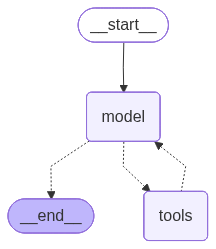

In [11]:
from IPython.display import display, Image
display("main_agent",Image(agent.get_graph(xray=True).draw_mermaid_png()))   

In [ ]:
# multi-agent system with separate sales and support agents. 
# each agent is a separate graph node, and handoff tools allow agents to transfer conversations to each other.
from typing import Literal
from langchain.agents import AgentState, create_agent
from langchain.messages import AIMessage, ToolMessage
from langchain.tools import tool, ToolRuntime
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from typing_extensions import NotRequired


# 1. Define state with active_agent tracker
class MultiAgentState(AgentState):
    active_agent: NotRequired[str]


# 2. Create handoff tools
@tool
def transfer_to_sales(
    runtime: ToolRuntime,
) -> Command:
    """Transfer to the sales agent."""
    last_ai_message = next(  
        msg for msg in reversed(runtime.state["messages"]) if isinstance(msg, AIMessage)  
    )  
    transfer_message = ToolMessage(  
        content="Transferred to sales agent from support agent",  
        tool_call_id=runtime.tool_call_id,  
    )  
    return Command(
        goto="sales_agent",
        update={
            "active_agent": "sales_agent",
            "messages": [last_ai_message, transfer_message],  
        },
        graph=Command.PARENT,
    )


@tool
def transfer_to_support(
    runtime: ToolRuntime,
) -> Command:
    """Transfer to the support agent."""
    last_ai_message = next(  
        msg for msg in reversed(runtime.state["messages"]) if isinstance(msg, AIMessage)  
    )  
    transfer_message = ToolMessage(  
        content="Transferred to support agent from sales agent",  
        tool_call_id=runtime.tool_call_id,  
    )  
    return Command(
        goto="support_agent",
        update={
            "active_agent": "support_agent",
            "messages": [last_ai_message, transfer_message],  
        },
        graph=Command.PARENT,
    )


# 3. Create agents with handoff tools
sales_agent = create_agent(
    model="ollama:gpt-oss:20b",
    tools=[transfer_to_support],
    system_prompt="You are a sales agent. Help with sales inquiries. If asked about technical issues or support, transfer to the support agent.",
)

support_agent = create_agent(
    model="ollama:gpt-oss:20b",
    tools=[transfer_to_sales],
    system_prompt="You are a support agent. Help with technical issues. If asked about pricing or purchasing, transfer to the sales agent.",
)


# 4. Create agent nodes that invoke the agents
def call_sales_agent(state: MultiAgentState) -> Command:
    """Node that calls the sales agent."""
    response = sales_agent.invoke(state)
    return response


def call_support_agent(state: MultiAgentState) -> Command:
    """Node that calls the support agent."""
    response = support_agent.invoke(state)
    return response


# 5. Create router that checks if we should end or continue
def route_after_agent(
    state: MultiAgentState,
) -> Literal["sales_agent", "support_agent", "__end__"]:
    """Route based on active_agent, or END if the agent finished without handoff."""
    messages = state.get("messages", [])

    # Check the last message - if it's an AIMessage without tool calls, we're done
    if messages:
        last_msg = messages[-1]
        if isinstance(last_msg, AIMessage) and not last_msg.tool_calls:  
            return "__end__"  

    # Otherwise route to the active agent
    active = state.get("active_agent", "sales_agent")
    return active if active else "sales_agent"


def route_initial(
    state: MultiAgentState,
) -> Literal["sales_agent", "support_agent"]:
    """Route to the active agent based on state, default to sales agent."""
    return state.get("active_agent") or "sales_agent" # default to sales agent


# 6. Build the graph
builder = StateGraph(MultiAgentState)
builder.add_node("sales_agent", call_sales_agent)
builder.add_node("support_agent", call_support_agent)

# Start with conditional routing based on initial active_agent (or default if provided)
builder.add_conditional_edges(START, route_initial, ["sales_agent", "support_agent"])

# After each agent, check if we should end or route to another agent
builder.add_conditional_edges(
    "sales_agent", route_after_agent, ["sales_agent", "support_agent", END]
)
builder.add_conditional_edges(
    "support_agent", route_after_agent, ["sales_agent", "support_agent", END]
)

graph = builder.compile()

# invoke: expected handoff from sales to support
result = graph.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Hi, I'm having trouble with my account login. Can you help?",
            }
        ]
    }
)
for msg in result["messages"]:
    msg.pretty_print()

# invoke: expected sales invocation, or handoff from support to sales
result = graph.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Hello, I need assistance with purchasing a new subscription plan.",
            }
        ]
    }
)
for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Hi, I'm having trouble with my account login. Can you help?
================================== Ai Message ==================================
Tool Calls:
  transfer_to_support (3916c332-1f28-49ec-a569-688b2565598b)
 Call ID: 3916c332-1f28-49ec-a569-688b2565598b
  Args:
================================= Tool Message =================================
Name: transfer_to_support

Transferred to support agent from sales agent
================================== Ai Message ==================================

Sure thing—let’s get you back into your account. Please try the following steps:

1. **Check your credentials**  
   * Make sure you’re using the correct email/username and password.  
   * Verify that the “Caps Lock” or “Num Lock” keys aren’t accidentally on.

2. **Reset your password**  
   * Click the “Forgot password?” link on the login page.  
   * Enter the email address you use for the account.  
   * C

'graph'

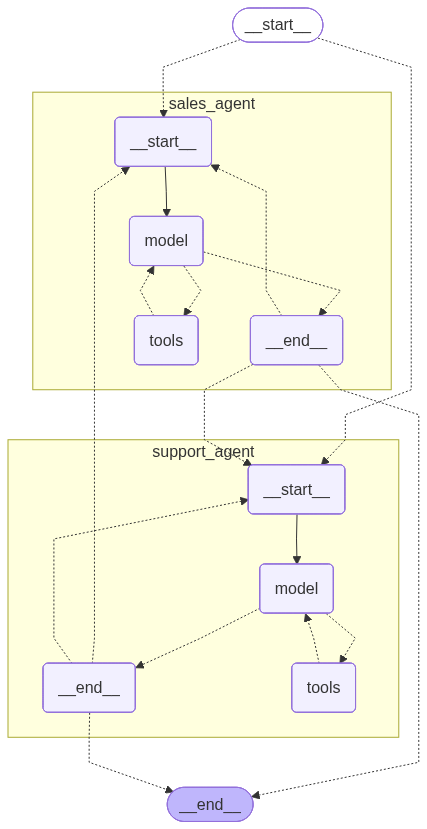

In [20]:
from IPython.display import display, Image
display("graph",Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
"""
Customer Support State Machine (single agent with steps)

state machine pattern:
A single agent dynamically changes its behavior based on the current_step state,
creating a state machine for sequential information collection.
"""

import uuid

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command
from typing import Callable, Literal
from typing_extensions import NotRequired

from langchain.agents import AgentState, create_agent
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse, SummarizationMiddleware
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage, ToolMessage
from langchain.tools import tool, ToolRuntime

model = ChatOllama(model="gpt-oss:20b", temperature=0, reasoning=True)


# Define the possible workflow steps
SupportStep = Literal["warranty_collector", "issue_classifier", "resolution_specialist"]


class SupportState(AgentState):
    """State for customer support workflow."""

    current_step: NotRequired[SupportStep]
    warranty_status: NotRequired[Literal["in_warranty", "out_of_warranty"]]
    issue_type: NotRequired[Literal["hardware", "software"]]


@tool
def record_warranty_status(
    status: Literal["in_warranty", "out_of_warranty"],
    runtime: ToolRuntime[None, SupportState],
) -> Command:
    """Record the customer's warranty status and transition to issue classification."""
    return Command(
        update={
            "messages": [
                ToolMessage(
                    content=f"Warranty status recorded as: {status}",
                    tool_call_id=runtime.tool_call_id,
                )
            ],
            "warranty_status": status,
            "current_step": "issue_classifier",
        }
    )


@tool
def record_issue_type(
    issue_type: Literal["hardware", "software"],
    runtime: ToolRuntime[None, SupportState],
) -> Command:
    """Record the type of issue and transition to resolution specialist."""
    return Command(
        update={
            "messages": [
                ToolMessage(
                    content=f"Issue type recorded as: {issue_type}",
                    tool_call_id=runtime.tool_call_id,
                )
            ],
            "issue_type": issue_type,
            "current_step": "resolution_specialist",
        }
    )


@tool
def escalate_to_human(reason: str) -> str:
    """Escalate the case to a human support specialist."""
    # In a real system, this would create a ticket, notify staff, etc.
    return f"Escalating to human support. Reason: {reason}"


@tool
def provide_solution(solution: str) -> str:
    """Provide a solution to the customer's issue."""
    return f"Solution provided: {solution}"


# Define prompts as constants
WARRANTY_COLLECTOR_PROMPT = """You are a customer support agent helping with device issues.

CURRENT STEP: Warranty verification

At this step, you need to:
1. Greet the customer warmly
2. Ask if their device is under warranty
3. Use record_warranty_status to record their response and move to the next step

Be conversational and friendly. Don't ask multiple questions at once."""

ISSUE_CLASSIFIER_PROMPT = """You are a customer support agent helping with device issues.

CURRENT STEP: Issue classification
CUSTOMER INFO: Warranty status is {warranty_status}

At this step, you need to:
1. Ask the customer to describe their issue
2. Determine if it's a hardware issue (physical damage, broken parts) or software issue (app crashes, performance)
3. Use record_issue_type to record the classification and move to the next step

If unclear, ask clarifying questions before classifying."""

RESOLUTION_SPECIALIST_PROMPT = """You are a customer support agent helping with device issues.

CURRENT STEP: Resolution
CUSTOMER INFO: Warranty status is {warranty_status}, issue type is {issue_type}

At this step, you need to:
1. For SOFTWARE issues: provide troubleshooting steps using provide_solution
2. For HARDWARE issues:
   - If IN WARRANTY: explain warranty repair process using provide_solution
   - If OUT OF WARRANTY: escalate_to_human for paid repair options

Be specific and helpful in your solutions."""


# Step configuration: maps step name to (prompt, tools, required_state)
STEP_CONFIG = {
    "warranty_collector": {
        "prompt": WARRANTY_COLLECTOR_PROMPT,
        "tools": [record_warranty_status],
        "requires": [],
    },
    "issue_classifier": {
        "prompt": ISSUE_CLASSIFIER_PROMPT,
        "tools": [record_issue_type],
        "requires": ["warranty_status"],
    },
    "resolution_specialist": {
        "prompt": RESOLUTION_SPECIALIST_PROMPT,
        "tools": [provide_solution, escalate_to_human],
        "requires": ["warranty_status", "issue_type"],
    },
}


@wrap_model_call
def apply_step_config(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    """Configure agent behavior based on the current step."""
    # Get current step (defaults to warranty_collector for first interaction)
    current_step = request.state.get("current_step", "warranty_collector")

    # Look up step configuration
    step_config = STEP_CONFIG[current_step]

    # Validate required state exists
    for key in step_config["requires"]:
        if request.state.get(key) is None:
            raise ValueError(f"{key} must be set before reaching {current_step}")

    # Format prompt with state values
    system_prompt = step_config["prompt"].format(**request.state)

    # Inject system prompt and step-specific tools
    request = request.override(
        system_prompt=system_prompt,
        tools=step_config["tools"],
    )

    return handler(request)


# Collect all tools from all step configurations
all_tools = [
    record_warranty_status,
    record_issue_type,
    provide_solution,
    escalate_to_human,
]

# Create the agent with step-based configuration and summarization
agent = create_agent(
    model,
    tools=all_tools,
    state_schema=SupportState,
    middleware=[
        apply_step_config,
        SummarizationMiddleware(
            model="gpt-4o-mini",
            trigger=("tokens", 4000),
            keep=("messages", 10)
        )
    ],
    checkpointer=InMemorySaver(),
)


# ============================================================================
# Test the workflow
# ============================================================================

if __name__ == "__main__":
    thread_id = str(uuid.uuid4())
    config = {"configurable": {"thread_id": thread_id}}

    result = agent.invoke(
        {"messages": [HumanMessage("Hi, my phone screen is cracked")]},
        config
    )

    result = agent.invoke(
        {"messages": [HumanMessage("Yes, it's still under warranty")]},
        config
    )

    result = agent.invoke(
        {"messages": [HumanMessage("The screen is physically cracked from dropping it")]},
        config
    )

    result = agent.invoke(
        {"messages": [HumanMessage("What should I do?")]},
        config
    )
    for msg in result['messages']:
        msg.pretty_print()

================================ Human Message =================================

Hi, my phone screen is cracked
================================== Ai Message ==================================
Tool Calls:
  record_warranty_status (423dcccb-0616-42ff-ab9b-8623b5ce2225)
 Call ID: 423dcccb-0616-42ff-ab9b-8623b5ce2225
  Args:
    status: unknown
================================= Tool Message =================================
Name: record_warranty_status

Error invoking tool 'record_warranty_status' with kwargs {'status': 'unknown'} with error:
 status: Input should be 'in_warranty' or 'out_of_warranty'
 Please fix the error and try again.
================================== Ai Message ==================================

Hello! I’m sorry to hear about your cracked screen. Before we dive into the next steps, could you let me know if your phone is still under warranty?
================================ Human Message =================================

Yes, it's still under warranty
============